In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
# === 1. Load data ===
df = pd.read_csv("T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/new_analysis_2/output_Notebook_2026/plot_features.csv") 

In [4]:
# === 2. Define AV and radial mean columns ===
av_cols = [ '90th_AV', '75th_AV', 'mean_AV', '25th_AV', '10th_AV']	#'mean_AV', , 	
radial_cols = ['mean_R', '90th_R', '10th_R', '25th_R', '75th_R']
meta_cols = ['condition', 'time_point']
feature_cols = av_cols + radial_cols

In [5]:
# === 3. Extract relevant columns ===
df = df[meta_cols + feature_cols].dropna()


In [6]:
# === 4. Scale the features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])
custom_palette = {
    'Cdh5CreERT2 mTmG': '#000000',    # black
    'Cdh5CreERT2;mTmG;SMAD4FloxFlox': '#0D79F2',   # blue
    'Cdh5CreERT2;mTmG;Alk1FloxFlox': '#C333CC'    # pink   
}


In [7]:
# === 5. Run PCA ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
#df['PC3'] = X_pca[:, 2]

In [8]:
# === 6. Compute the mean PCA coords of ALL P8 samples ===
p8_center = df[df['time_point'] == 'P8'][['PC1', 'PC2']].mean().values

df['PC1_centered'] = df['PC1'] - p8_center[0]
df['PC2_centered'] = df['PC2'] - p8_center[1]
#df['PC3_centered'] = df['PC3'] - p8_center[2]

# Define combined group label for diagnostics and PERMANOVA/PERMDISP
df['condition'] = df['condition'].astype(str)
df['time_point'] = df['time_point'].astype(str)
df['group'] = df['condition'] + '_' + df['time_point']

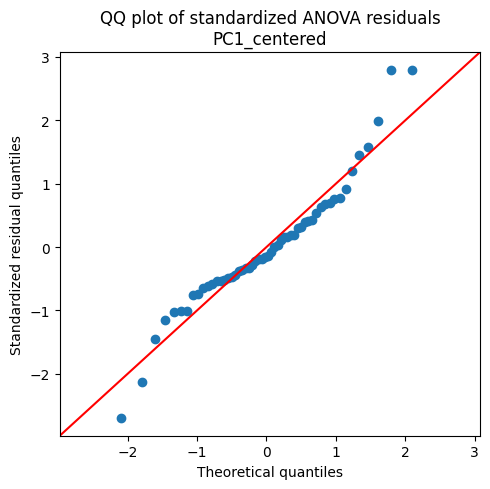

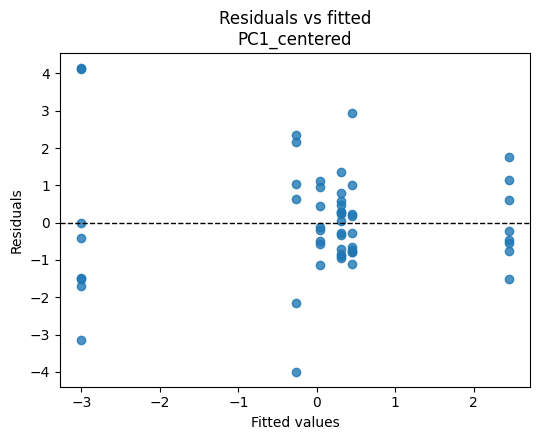

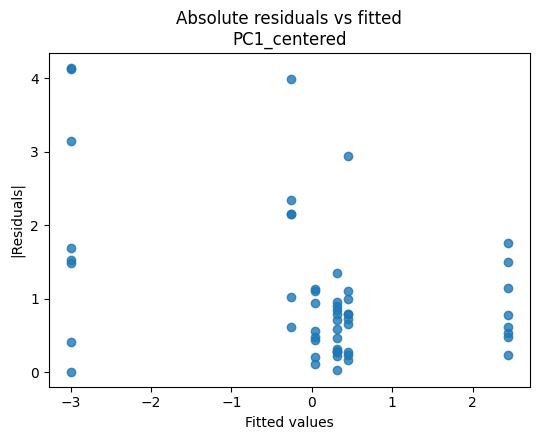

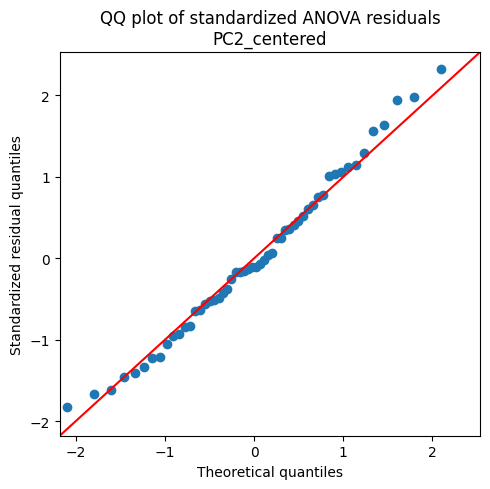

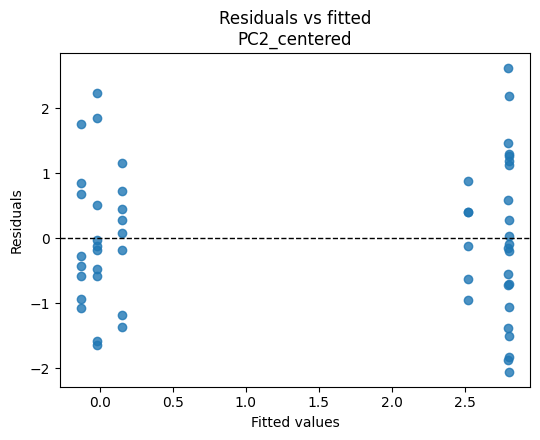

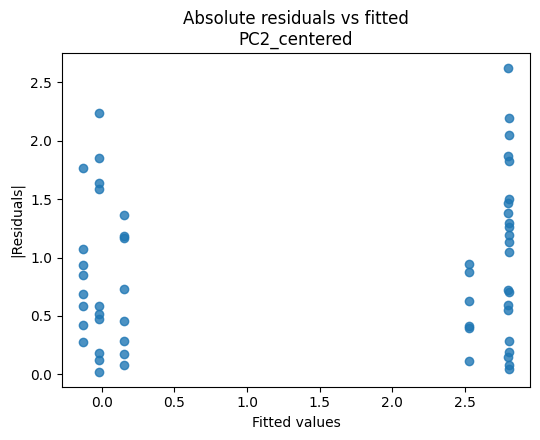


ANOVA assumption-check summary:
                                                                                              0  \
endpoint                                                                           PC1_centered   
model                                               PC1_centered ~ C(condition) * C(time_point)   
n_samples                                                                                    54   
n_groups                                                                                      6   
shapiro_wilk_stat                                                                      0.950359   
shapiro_wilk_p                                                                         0.025791   
shapiro_wilk_passed_p_gt_0_05                                                             False   
ks_stat_standardized_residuals                                                         0.096123   
ks_p_standardized_residuals                                                 

C:\Users\ooppenh\.conda\envs\Jupyter_Notebooks\lib\site-packages\skbio\stats\ordination\_principal_coordinate_analysis.py:157: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(



PERMDISP results:
method name               PERMDISP
test statistic name        F-value
sample size                     54
number of groups                 6
test statistic            1.073477
p-value                      0.321
number of permutations         999
Name: PERMDISP results, dtype: object

Done with PCA diagnostics.


In [10]:
# =========================================================
# DIAGNOSTIC BLOCK FOR PCA-BASED IN VIVO ANALYSES
# Normality + homogeneity of variance for PC1/PC2 ANOVA
# PERMDISP for PERMANOVA dispersion assumption
# =========================================================

import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt

from skbio.stats.distance import DistanceMatrix
from skbio.stats.distance import permdisp
from scipy.spatial.distance import pdist, squareform

# Optional: set output directory
diagnostic_output_dir = "PCA_diagnostics_270426"
os.makedirs(diagnostic_output_dir, exist_ok=True)

alpha = 0.05

# Make sure grouping variables are strings/categorical
df["condition"] = df["condition"].astype(str)
df["time_point"] = df["time_point"].astype(str)
df["group"] = df["condition"] + "_" + df["time_point"]

# =========================================================
# 1. Function for ANOVA diagnostics on individual PCs
# =========================================================

def run_pc_anova_diagnostics(df, pc_col, output_dir, alpha=0.05):
    """
    Runs residual diagnostics for:
    PC ~ condition * time_point

    Tests:
    - Shapiro-Wilk residual normality
    - Kolmogorov-Smirnov test on standardized residuals
    - Brown-Forsythe / median-centered Levene test across condition-time groups
    - Spearman correlation between fitted values and absolute residuals
    - QQ plot of standardized residuals
    - residuals vs fitted plot
    - absolute residuals vs fitted plot
    """

    data = df[["condition", "time_point", "group", pc_col]].dropna().copy()

    model = smf.ols(
        f"{pc_col} ~ C(condition) * C(time_point)",
        data=data
    ).fit()

    data["fitted"] = model.fittedvalues
    data["residual"] = model.resid
    data["abs_residual"] = np.abs(model.resid)

    residuals = data["residual"].dropna()

    std_residuals = (
        residuals - residuals.mean()
    ) / residuals.std(ddof=1)

    # -----------------------------
    # Normality tests
    # -----------------------------
    shapiro_stat, shapiro_p = stats.shapiro(residuals)

    ks_stat, ks_p = stats.kstest(std_residuals, "norm")

    # -----------------------------
    # Homogeneity of variance
    # Brown-Forsythe = Levene centered on median
    # -----------------------------
    groups = [
        group_df[pc_col].dropna().values
        for _, group_df in data.groupby("group")
        if len(group_df[pc_col].dropna().values) >= 2
    ]

    if len(groups) >= 2:
        brown_forsythe_stat, brown_forsythe_p = stats.levene(
            *groups,
            center="median"
        )
    else:
        brown_forsythe_stat, brown_forsythe_p = np.nan, np.nan

    # Additional Prism-like heteroscedasticity diagnostic:
    # correlation between fitted values and absolute residuals
    spearman_r, spearman_p = stats.spearmanr(
        data["fitted"],
        data["abs_residual"]
    )

    # -----------------------------
    # Scenario classification
    # Based on Shapiro-Wilk + Brown-Forsythe
    # -----------------------------
    normality_passed = shapiro_p > alpha
    variance_passed = brown_forsythe_p > alpha if not pd.isna(brown_forsythe_p) else np.nan

    if normality_passed and variance_passed:
        scenario = "1: normality and homogeneity satisfied"
    elif normality_passed and not variance_passed:
        scenario = "2: normality satisfied, homogeneity violated"
    elif not normality_passed and variance_passed:
        scenario = "3: homogeneity satisfied, normality violated"
    elif not normality_passed and not variance_passed:
        scenario = "4: normality and homogeneity violated"
    else:
        scenario = "not classified"

    # -----------------------------
    # Save residual table
    # -----------------------------
    data.to_csv(
        os.path.join(output_dir, f"{pc_col}_anova_residuals.csv"),
        index=False
    )

    # -----------------------------
    # Save ANOVA table
    # -----------------------------
    anova_table = sm.stats.anova_lm(model, typ=2)
    anova_table.to_csv(
        os.path.join(output_dir, f"{pc_col}_two_way_ANOVA_table.csv")
    )

    # -----------------------------
    # Save model summary
    # -----------------------------
    with open(
        os.path.join(output_dir, f"{pc_col}_two_way_ANOVA_model_summary.txt"),
        "w",
        encoding="utf-8"
    ) as f:
        f.write(model.summary().as_text())

    # -----------------------------
    # QQ plot of standardized residuals
    # -----------------------------
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111)

    sm.qqplot(std_residuals, line="45", ax=ax)

    ax.set_title(f"QQ plot of standardized ANOVA residuals\n{pc_col}")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Standardized residual quantiles")

    fig.tight_layout()
    fig.savefig(
        os.path.join(output_dir, f"{pc_col}_qqplot_standardized_residuals.png"),
        bbox_inches="tight"
    )
    plt.show()

    # -----------------------------
    # Residuals vs fitted
    # -----------------------------
    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    ax.scatter(data["fitted"], data["residual"], alpha=0.8)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)

    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title(f"Residuals vs fitted\n{pc_col}")

    fig.tight_layout()
    fig.savefig(
        os.path.join(output_dir, f"{pc_col}_residuals_vs_fitted.png"),
        bbox_inches="tight"
    )
    plt.show()

    # -----------------------------
    # Absolute residuals vs fitted
    # -----------------------------
    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    ax.scatter(data["fitted"], data["abs_residual"], alpha=0.8)

    ax.set_xlabel("Fitted values")
    ax.set_ylabel("|Residuals|")
    ax.set_title(f"Absolute residuals vs fitted\n{pc_col}")

    fig.tight_layout()
    fig.savefig(
        os.path.join(output_dir, f"{pc_col}_abs_residuals_vs_fitted.png"),
        bbox_inches="tight"
    )
    plt.show()

    # -----------------------------
    # Return summary
    # -----------------------------
    summary = {
        "endpoint": pc_col,
        "model": f"{pc_col} ~ C(condition) * C(time_point)",
        "n_samples": len(data),
        "n_groups": data["group"].nunique(),

        "shapiro_wilk_stat": shapiro_stat,
        "shapiro_wilk_p": shapiro_p,
        "shapiro_wilk_passed_p_gt_0_05": normality_passed,

        "ks_stat_standardized_residuals": ks_stat,
        "ks_p_standardized_residuals": ks_p,
        "ks_passed_p_gt_0_05": ks_p > alpha,

        "brown_forsythe_levene_stat": brown_forsythe_stat,
        "brown_forsythe_levene_p": brown_forsythe_p,
        "brown_forsythe_passed_p_gt_0_05": variance_passed,

        "spearman_fitted_abs_residual_r": spearman_r,
        "spearman_fitted_abs_residual_p": spearman_p,
        "spearman_no_heteroscedasticity_passed_p_gt_0_05": spearman_p > alpha,

        "reviewer_scenario_based_on_shapiro_and_brown_forsythe": scenario,
    }

    return summary


# =========================================================
# 2. Run diagnostics for PC1 and PC2
# =========================================================

diagnostic_summaries = []

for pc_col in ["PC1_centered", "PC2_centered"]:
    diagnostic_summaries.append(
        run_pc_anova_diagnostics(
            df=df,
            pc_col=pc_col,
            output_dir=diagnostic_output_dir,
            alpha=alpha
        )
    )

diagnostic_summary_df = pd.DataFrame(diagnostic_summaries)

diagnostic_summary_df.to_csv(
    os.path.join(
        diagnostic_output_dir,
        "PC1_PC2_ANOVA_assumption_check_summary.csv"
    ),
    index=False
)

print("\nANOVA assumption-check summary:")
print(diagnostic_summary_df.T)


# =========================================================
# 3. PERMDISP for PERMANOVA
# =========================================================
# PERMANOVA can be influenced by differences in group dispersion.
# PERMDISP tests homogeneity of multivariate dispersion across groups.

coords = df[["PC1_centered", "PC2_centered"]].dropna().values

# Need matching IDs/grouping for rows without NA
df_permdisp = df[["PC1_centered", "PC2_centered", "group"]].dropna().copy()
ids = df_permdisp.index.astype(str)

coords = df_permdisp[["PC1_centered", "PC2_centered"]].values

dmatrix = DistanceMatrix(
    squareform(pdist(coords)),
    ids=ids
)

grouping = df_permdisp["group"].copy()
grouping.index = ids

permdisp_results = permdisp(
    dmatrix,
    grouping=grouping,
    permutations=999
)

print("\nPERMDISP results:")
print(permdisp_results)

# Save PERMDISP output
permdisp_df = pd.DataFrame({
    "test": ["PERMDISP"],
    "method": ["homogeneity of multivariate dispersion"],
    "grouping": ["condition_time_point"],
    "permutations": [999],
    "test_statistic": [permdisp_results["test statistic"]],
    "p_value": [permdisp_results["p-value"]],
    "number_of_groups": [df_permdisp["group"].nunique()],
    "sample_size": [len(df_permdisp)]
})

permdisp_df.to_csv(
    os.path.join(
        diagnostic_output_dir,
        "PC1_PC2_PERMDISP_homogeneity_of_dispersion.csv"
    ),
    index=False
)

print("\nDone with PCA diagnostics.")

In [32]:
# === 7. Compute centroids per condition & timepoint ===
centroids = (
    df.groupby(['condition', 'time_point'])[['PC1_centered', 'PC2_centered']]
      .mean()
      .reset_index()
)

C:\Users\ooppenh\AppData\Local\Temp\ipykernel_29844\3927231342.py:14: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


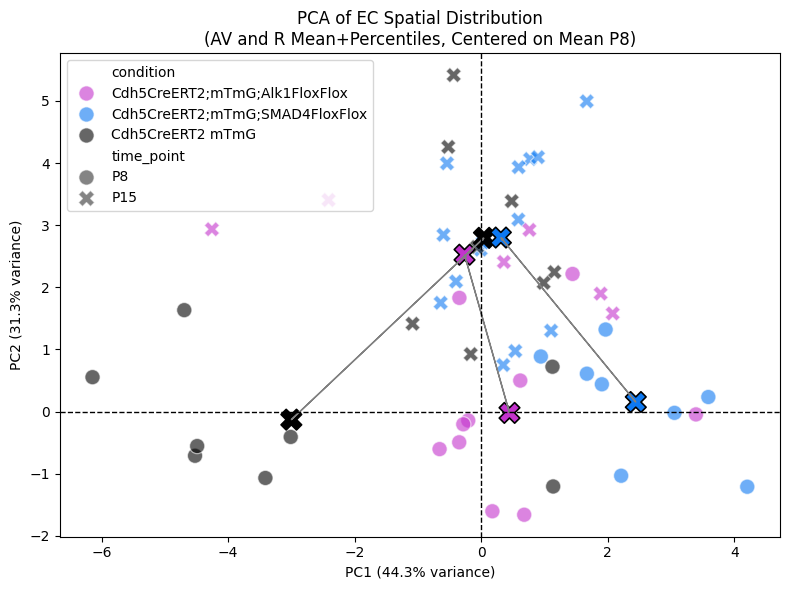

In [33]:
plt.figure(figsize=(8, 6))

# Individual samples
sns.scatterplot(
    data=df,
    x='PC1_centered', y='PC2_centered',
    hue='condition',
    style='time_point', palette=custom_palette,
    s=120,
    alpha=0.6
)

# Centroids
sns.scatterplot(
    data=centroids,
    x='PC1_centered', y='PC2_centered',
    hue='condition',
    style='time_point', palette=custom_palette,
    markers='X',
    s=220,
    legend=False,
    edgecolor='black'
)

# Arrows: P8 → P15 within each condition
for cond in centroids['condition'].unique():
    p8 = centroids[(centroids['condition'] == cond) & (centroids['time_point'] == 'P8')]
    p15 = centroids[(centroids['condition'] == cond) & (centroids['time_point'] == 'P15')]
    if not p8.empty and not p15.empty:
        plt.arrow(
            p8['PC1_centered'].values[0],
            p8['PC2_centered'].values[0],
            p15['PC1_centered'].values[0] - p8['PC1_centered'].values[0],
            p15['PC2_centered'].values[0] - p8['PC2_centered'].values[0],
            color='gray',
            width=0.003,
            head_width=0.03,
            length_includes_head=True
        )

# Reference lines: mean P8 = (0, 0)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.title("PCA of EC Spatial Distribution\n(AV and R Mean+Percentiles, Centered on Mean P8)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()

plt.savefig("pca PC1-2_AV_R_mean_percentiles_centered_on_P8_270426.pdf", format='pdf')
plt.show()

In [36]:
#PERMANOVA on both PC1+PC2
from skbio.stats.distance import permanova
from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform

# Create 3D distance matrix from PCA coords
coords = df[['PC1_centered', 'PC2_centered']].values
dmatrix = DistanceMatrix(squareform(pdist(coords)), ids=df.index.astype(str))

# Define grouping labels
df['group'] = df['condition'] + '_' + df['time_point'].astype(str)
grouping = df['group']
grouping.index = df.index.astype(str)  # Ensure matching string indices

# Run PERMANOVA
results = permanova(dmatrix, grouping=grouping, permutations=999)
print(results)
results.to_csv("AV_R_PC1-2_mean_percentiles_PERMANOVA_summary_270426.csv", index=False)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                      54
number of groups                  6
test statistic            11.821687
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


In [37]:
#Vector analysis
import numpy as np

vector_data = []

# Loop over genotypes
for cond in centroids['condition'].unique():
    p8 = centroids[(centroids['condition'] == cond) & (centroids['time_point'] == 'P8')]
    p15 = centroids[(centroids['condition'] == cond) & (centroids['time_point'] == 'P15')]

    if not p8.empty and not p15.empty:
        delta_pc1 = p15['PC1_centered'].values[0] - p8['PC1_centered'].values[0]
        delta_pc2 = p15['PC2_centered'].values[0] - p8['PC2_centered'].values[0]
      #  delta_pc3 = p15['PC3_centered'].values[0] - p8['PC3_centered'].values[0]
        magnitude = np.sqrt(delta_pc1**2 + delta_pc2**2) #+ delta_pc3**2)
        angle_deg12 = np.degrees(np.arctan2(delta_pc2, delta_pc1))
        #angle_deg23 = np.degrees(np.arctan2(delta_pc3, delta_pc2))
        #angle_deg13 = np.degrees(np.arctan2(delta_pc3, delta_pc1))

        vector_data.append({
            'condition': cond,
            'ΔPC1': delta_pc1,
            'ΔPC2': delta_pc2,
         #   'ΔPC3': delta_pc3,
            'magnitude': magnitude,
            'angle_deg1-2': angle_deg12,
          #  'angle_deg2-3': angle_deg23,
           # 'angle_deg1-3': angle_deg13
            
        })

df_vectors = pd.DataFrame(vector_data)
print(df_vectors)
df_vectors.to_csv("AV_R_PC1-2_mean_percentiles_vector_shifts_summary_270426.csv", index=False)


                        condition      ΔPC1      ΔPC2  magnitude  angle_deg1-2
0                Cdh5CreERT2 mTmG  3.045088  2.925180   4.488924     43.849416
1   Cdh5CreERT2;mTmG;Alk1FloxFlox -0.711003  2.545346   3.050494    105.606891
2  Cdh5CreERT2;mTmG;SMAD4FloxFlox -2.133082  2.646894   3.725223    128.864689


In [38]:
loadings = pd.DataFrame(pca.components_, columns=feature_cols, index=['PC1', 'PC2'])
print(loadings.T.sort_values(by='PC1', ascending=False))  # or by PC2
loadings.to_csv("PCA_PC1_2_component_loadings_AV_R_mean_percentiles_270426.csv", index=False)

              PC1       PC2
mean_R   0.462195  0.122352
25th_R   0.448023  0.054316
75th_R   0.424681  0.155034
10th_R   0.399554  0.104131
90th_R   0.382680  0.241364
10th_AV -0.018494  0.069392
25th_AV -0.065698  0.439303
mean_AV -0.159671  0.521619
75th_AV -0.165127  0.491743
90th_AV -0.204426  0.421004


In [40]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Make sure collection_time is treated as categorical
df['time_point'] = df['time_point'].astype(str)

model = ols('PC2_centered ~ C(condition) * C(time_point)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

anova_table.to_csv("PC2_ANOVA_AV-R_270426.csv", index=False)

                               sum_sq    df          F        PR(>F)
C(condition)                 0.375693   2.0   0.134123  8.748086e-01
C(time_point)               93.882612   1.0  67.032710  1.149165e-10
C(condition):C(time_point)   0.306676   2.0   0.109484  8.965195e-01
Residual                    67.226364  48.0        NaN           NaN
